# Neural Network Forecast-Error Correction for ECB SPF Forecasts

This notebook trains the neural networks on the final SPF modelling dataset.

The target is:

```text
forecast_error = actual_value - rolling_1y_forecast
```

The neural network predicts `forecast_error`. The corrected forecast is:

```text
corrected_forecast = rolling_1y_forecast + predicted_error
```

Training setup: feed-forward networks, validation-based hyperparameter
selection, early stopping, and seed ensembles, refit once per test year on an
expanding window.

## Performance notes

The dataset is small by deep-learning standards, so the bottleneck is the number
of refits (architectures x test years x hyperparameters x ensemble seeds), not
data transfer. To keep a full run fast on a Colab GPU:

- no `DataLoader`
- tensors are moved to the selected device before each refit
- mini-batches are created by shuffling tensor indices on-device
- CUDA uses TF32 matmul when available

The SPF dataset has missing values in some predictors, so each
train/validation/test split is first imputed and scaled using the training
sample only; only the clean numeric matrices become tensors.

---
## Step 0: Install Dependencies & Imports

In [1]:
from pathlib import Path
from copy import deepcopy
import warnings
import time

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

warnings.filterwarnings("ignore")

HAS_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda")

# Resolve paths from the repository root so the notebook works after cloning.
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "Data").exists() and (folder / "README.md").exists():
            return folder
    return start


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "Data"

DATA_DIR = DATA_ROOT

print(f"CUDA: {'Y' if HAS_CUDA else 'N'}")
if not HAS_CUDA:
    raise RuntimeError("CUDA is not available. In Colab, enable a GPU runtime before training.")


CUDA: Y | SmokeTest: N


---
## Step 1: Load the Final SPF Modelling Dataset

The notebook now expects the macro-matched final dataset created by
`step3_final_dataset.ipynb`.

The notebook assumes it is being run in Google Colab. The dataset is copied
from Google Drive into the Colab runtime before training:

```text
/content/drive/MyDrive/final_model_dataset_macro_matched.csv
```

Copying once to `/content/data` avoids reading repeatedly from Google Drive
during training.

In [2]:
LOCAL_FILE = DATA_DIR / "final_model_dataset.csv"

if not LOCAL_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {LOCAL_FILE}. Add Data/final_model_dataset.csv to the repo, "
        "or run the data processing notebook first."
    )

panel = pd.read_csv(LOCAL_FILE)

panel = panel.sort_values(
    ["survey_year", "survey_quarter", "variable", "fct_source"]
).reset_index(drop=True)

print(f"Panel shape: {panel.shape}")


Panel shape: (9810, 178)


---
## Step 2: Identify Feature Columns and Target

The target is `forecast_error`, the realized value minus the SPF rolling
one-year-ahead forecast.

The model keeps every numeric column after excluding metadata, outcome columns,
and the extra SPF horizon forecasts (their consensus and shape features stay in).

In [3]:
# ====================================================
# Separate ID columns, target, and features
# ====================================================

# Train separate models for inflation and real GDP growth.
TARGET_VARIABLES = ["HICP", "RGDP"]

# Main target: the correction the NN should learn.
target_col = "forecast_error"

# Numeric columns that should not be NN inputs.
excluded_feature_cols = {
    # numeric identifiers / metadata
    "survey_year",
    "survey_quarter",
    "fct_source",

    # outcomes / leakage
    "actual_value",
    "forecast_error",
    "abs_forecast_error",
    "squared_forecast_error",

    # extra raw SPF horizon forecasts
    "rolling_2y_forecast",
    "rolling_longer_forecast",
    "next_year_forecast",
    "current_year_forecast",

    # only useful in a pooled HICP/RGDP model
    "variable_RGDP",
}

feature_cols = [
    col for col in panel.select_dtypes(include="number").columns
    if col not in excluded_feature_cols
]

model_data = panel.copy()

print(f"Total input features: {len(feature_cols)}")

Total input features: 156


---
## Step 3: Define Sample Splits

The split must be chronological. A random split would leak information from
future macroeconomic periods into the training sample.

The setup uses an expanding training window, a four-year validation window, and
one test year at a time. Example for test year 2015: train = 2000-2010,
valid = 2011-2014, test = 2015; the next refit shifts everything one year forward.

In [4]:
# ====================================================
# Expanding-window split helpers
# ====================================================

VALID_YEARS = 4
TEST_START_YEAR = 2012


# The panel is sorted by year, so each year is one contiguous block of rows.
# Slices instead of boolean masks keep the repeated annual refits cheap.
def build_year_slices(data: pd.DataFrame) -> dict[int, slice]:
    years = data["survey_year"].to_numpy(copy=True)
    unique_years, first_idx = np.unique(years, return_index=True)

    slices = {}
    for idx, year in enumerate(unique_years):
        start = int(first_idx[idx])
        end = int(first_idx[idx + 1]) if idx + 1 < len(first_idx) else len(years)
        slices[int(year)] = slice(start, end)
    return slices


# One split per test year. For test year 2015: train = start-2010,
# valid = 2011-2014, test = 2015.
def build_splits_for_data(data: pd.DataFrame) -> list[dict]:
    train_start_year = int(data["survey_year"].min())
    test_end_year = int(data["survey_year"].max())

    splits = []
    for test_year in range(TEST_START_YEAR, test_end_year + 1):
        train_end_year = test_year - VALID_YEARS - 1
        valid_start_year = train_end_year + 1
        valid_end_year = test_year - 1

        if train_end_year < train_start_year:
            continue

        splits.append({
            "train": (train_start_year, train_end_year),
            "valid": (valid_start_year, valid_end_year),
            "test":  (test_year, test_year),
        })
    return splits


---
## Step 4: Define the Neural Network Architecture

The model is a feed-forward neural network:

```text
Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x L -> Linear -> predicted_error
```

The output layer has one neuron because the target is one continuous number:
the SPF forecast error. Dropout with `p=0.2` is added after each hidden-layer
ReLU to reduce overfitting in the smaller HICP/RGDP training samples.

In [ ]:
# Forecast-error NN

# MLP mapping the feature vector to one number: the predicted correction to the
# rolling 1y SPF forecast.
# Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x L -> Linear(1)
# BatchNorm earns its place here: the macro features have very different scales
# even after standardization. Dropout 0.2 was enough - higher values made the
# small nets underfit.
class SPFNet(nn.Module):

    def __init__(self, input_dim: int, hidden_sizes: list[int]):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.2))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))  # one output: the error is a single number
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)  # (n,1) -> (n,) so it matches y


# Architecture

NN_ARCHITECTURES = {
    "NN1": [32],
    "NN2": [32, 16],
    "NN3": [32, 16, 8],
    "NN4": [32, 16, 8, 4],
    "NN5": [32, 16, 8, 4, 2],
}


---
## Step 5: Training Utilities

Adam optimizer, MSE loss, optional L1 penalty, and early stopping on validation loss.

In [ ]:
# Training funktions 

TRAIN_LOSS = nn.MSELoss(reduction="none")


# Mean loss, optionally weighted. The weights exist because one survey round can
# have 50 forecasters and another 25 - without them the busy rounds dominate.
def weighted_loss(
    preds: torch.Tensor,
    target: torch.Tensor,
    sample_weights: torch.Tensor | None = None,
) -> torch.Tensor:
    loss_per_obs = TRAIN_LOSS(preds, target).reshape(-1)
    if sample_weights is None:
        return loss_per_obs.mean()

    weights = sample_weights.reshape(-1).to(loss_per_obs.device)
    denominator = torch.clamp(weights.sum(), min=1e-12)
    return (loss_per_obs * weights).sum() / denominator
# Apply L1 only to Linear layer weights, not BatchNorm.
def select_l1_parameters(model: nn.Module) -> list[torch.Tensor]:
    params = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            params.append(module.weight)
    return params


# Compute the L1 norm over a precomputed parameter list.
def l1_penalty(parameters: list[torch.Tensor]) -> torch.Tensor:
    l1 = None
    for param in parameters:
        term = param.abs().sum()
        l1 = term if l1 is None else l1 + term
    if l1 is None:
        return torch.tensor(0.0, device=DEVICE)
    return l1


# Clone model weights onto CPU so they can be reused later.
def snapshot_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


# Run inference on a tensor that is already on the target device.
#
# Returns a tensor on the SAME device as the input X.
def predict_in_batches(
    model: nn.Module,
    X: torch.Tensor,
    batch_size: int,
    device: torch.device | None = None,
) -> torch.Tensor:
    if X.shape[0] == 0:
        return torch.empty(0, dtype=torch.float32, device=X.device)

    preds = []
    model.eval()
    with torch.inference_mode():
        for start in range(0, X.shape[0], batch_size):
            stop = start + batch_size
            preds.append(model(X[start:stop]))

    return torch.cat(preds, dim=0)


# Evaluate the validation loss used for early stopping and HP tuning.
def evaluate_validation_loss(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    batch_size: int,
    sample_weights: torch.Tensor | None = None,
) -> float:
    preds = predict_in_batches(model, X, batch_size=batch_size)
    return weighted_loss(preds, y, sample_weights).item()




---
## Step 6: Train Engine

This is the core training routine for one neural network. It takes the prepared train and validation tensors, updates the model weights with Adam, uses validation loss for early stopping, and returns the best version of the model.


In [ ]:
# ====================================================
# Train a single neural network with early stopping
# ====================================================

# Train one network with Adam + early stopping on validation loss.
# there is no DataLoader and no per-batch host-to-device copy.
# Returns the restored best model and its validation loss.
def train_single_nn(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_valid: torch.Tensor,
    y_valid: torch.Tensor,
    train_weights: torch.Tensor | None = None,
    valid_weights: torch.Tensor | None = None,
    lr: float = 0.001,
    l1_lambda: float = 1e-5,
    batch_size: int = 10_000,
    max_epochs: int = 100,
    patience: int = 5,
    inference_batch_size: int | None = None,
) -> tuple[nn.Module, float]:
    if inference_batch_size is None:
        inference_batch_size = INFERENCE_BATCH_SIZE

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    l1_params = select_l1_parameters(model)

    n_train = X_train.shape[0]
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        # Shuffle indices on-device; no host round-trip.
        perm = torch.randperm(n_train, device=X_train.device)

        # BatchNorm needs at least two observations per training minibatch.
        # If the final tail would have one row, merge it into the previous batch.
        start = 0
        while start < n_train:
            stop = min(start + batch_size, n_train)
            if n_train - stop == 1:
                stop = n_train

            idx = perm[start:stop]
            X_batch = X_train[idx]
            y_batch = y_train[idx]
            w_batch = train_weights[idx] if train_weights is not None else None

            optimizer.zero_grad(set_to_none=True)
            preds = model(X_batch)
            loss = weighted_loss(preds, y_batch, w_batch)
            if l1_lambda:
                loss = loss + l1_lambda * l1_penalty(l1_params)
            loss.backward()
            optimizer.step()

            start = stop

        val_loss = evaluate_validation_loss(
            model,
            X_valid,
            y_valid,
            batch_size=inference_batch_size,
            sample_weights=valid_weights,
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = snapshot_state_dict(model)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


---
## Step 7: Hyperparameter Tuning via Validation

The neural network has several choices that affect how it learns, especially the learning rate and the strength of L1 regularization. Instead of choosing these by looking at the test years, the notebook chooses them inside each refit using only the validation window.

For each architecture and each annual refit, the notebook searches over a small grid of learning rates and L1 penalty strengths.


In [8]:
# ====================================================
# Hyperparameter grid
# ====================================================

FULL_HYPERPARAM_GRID = [
    {"lr": 0.001, "l1_lambda": 1e-5},
    {"lr": 0.01,  "l1_lambda": 1e-5},
    {"lr": 0.001, "l1_lambda": 1e-3},
    {"lr": 0.01,  "l1_lambda": 1e-3},
    {"lr": 0.001, "l1_lambda": 1e-2},
    {"lr": 0.01,  "l1_lambda": 1e-2},
]

HYPERPARAM_GRID = FULL_HYPERPARAM_GRID
MAX_EPOCHS = 100
PATIENCE = 6
N_ENSEMBLE = 10

# Training constants.
BATCH_SIZE = 150
INFERENCE_BATCH_SIZE = 8000

# Numerical-stability guards for train-only preprocessing.
# Some early-window predictors are almost constant after imputation;
# without a std floor, later observations can be divided by ~0.
MIN_FEATURE_STD = 1e-6

# Sample-weight toggle.
# When True, each variable x survey_round x rolling_1y_target block receives
# equal total training/validation weight. This prevents years/periods with
# more forecaster responses from dominating the loss simply because there
# are more rows for the same macro forecast episode.
USE_TARGET_PERIOD_WEIGHTS = True
TARGET_PERIOD_WEIGHT_COLS = ["variable", "survey_round", "rolling_1y_target"]

# Robust target toggle. Bounds are estimated from the train split only,
# then applied to train/validation targets used for learning and tuning.
# Test targets stay unmodified for honest out-of-sample evaluation.
WINSORIZE_TARGET = True
TARGET_WINSOR_LOWER_Q = 0.05
TARGET_WINSOR_UPPER_Q = 0.95

# Prediction calibration toggles.
# Clipping prevents out-of-distribution macro inputs from producing
# implausibly large forecast-error corrections. Bounds are estimated from
# the current training window only.
CLIP_PREDICTIONS = True
PREDICTION_CLIP_LOWER_Q = 0.01
PREDICTION_CLIP_UPPER_Q = 0.99

# OLS shrinkage calibrates the correction magnitude on the validation window:
# alpha = sum(pred_valid * error_valid) / sum(pred_valid ** 2), clamped to [0, 1].
USE_OLS_SHRINKAGE = True
SHRINKAGE_ALPHA_MIN = 0.01
SHRINKAGE_ALPHA_MAX = 0.99



---
## Step 8: Data Preparation Helpers

Before the neural network can train, each chronological split has to be turned into clean numerical tensors. This step keeps the procedure honest by estimating imputation, scaling, clipping, and weighting rules from the training window only, then applying those same rules to validation and test data.

The raw feature matrix has missing values, so each split is preprocessed before tensor conversion:

1. fit medians, means, and standard deviations on the training sample only
2. median-impute train/validation/test features
3. standardize train/validation/test features using training moments
4. convert the clean arrays to PyTorch tensors


In [9]:
# ====================================================
# Split extraction and train-only preprocessing.
# Everything in this section is fitted on the training window ONLY and then
# applied to valid/test. That train-only rule is the most important thing here:
# fitting the imputer or scaler on the full panel would leak future data into
# early training windows.
# ====================================================

active_variable = None
active_model_data = None
active_year_slices = None
active_splits = None


# Select one macro variable and build its split metadata.
def set_active_variable(variable: str) -> list[dict]:
    global active_variable, active_model_data, active_year_slices, active_splits

    active_variable = variable
    active_model_data = (
        model_data
        .loc[model_data["variable"] == variable]
        .sort_values(["survey_year", "survey_quarter", "fct_source"])
        .copy()
    )
    active_year_slices = build_year_slices(active_model_data)
    active_splits = build_splits_for_data(active_model_data)

    return active_splits


# Return the contiguous row slice for an inclusive year range.
def slice_for_year_range(start_year: int, end_year: int) -> slice:
    start = active_year_slices[start_year].start
    stop = active_year_slices[end_year].stop
    return slice(start, stop)


# Fit median imputation and standardization using training data only.
#
# The std floor is important for early expanding-window splits. A variable
# can be almost constant in 1999-2007 but move later, and dividing by a
# near-zero training std would create enormous validation/test inputs.
def fit_preprocessor(X_train_df: pd.DataFrame) -> tuple[pd.Series, pd.Series, pd.Series]:
    medians = X_train_df.median(axis=0).fillna(0.0)
    X_train_filled = X_train_df.fillna(medians)

    means = X_train_filled.mean(axis=0).fillna(0.0)
    raw_stds = X_train_filled.std(axis=0, ddof=0).fillna(0.0)
    stds = raw_stds.mask(raw_stds < MIN_FEATURE_STD, 1.0)
    return medians, means, stds


# Apply training-sample imputation and scaling to a feature frame.
def apply_preprocessor(
    X_df: pd.DataFrame,
    medians: pd.Series,
    means: pd.Series,
    stds: pd.Series,
) -> np.ndarray:
    X_clean = X_df.fillna(medians)
    X_scaled = (X_clean - means) / stds
    return X_scaled.to_numpy(dtype=np.float32, copy=True)


# Estimate target clipping bounds from the training split only.
def fit_target_winsor_bounds(y_train: pd.Series) -> tuple[float, float]:
    lower = float(y_train.quantile(TARGET_WINSOR_LOWER_Q))
    upper = float(y_train.quantile(TARGET_WINSOR_UPPER_Q))
    return lower, upper


# Clip targets using pre-estimated train-split bounds.
def apply_target_winsor(y: pd.Series, lower: float, upper: float) -> pd.Series:
    if not WINSORIZE_TARGET:
        return y
    return y.clip(lower=lower, upper=upper)


# Estimate prediction clipping bounds from the training split only.
def fit_prediction_clip_bounds(y_train_raw: pd.Series) -> tuple[float, float]:
    lower = float(y_train_raw.quantile(PREDICTION_CLIP_LOWER_Q))
    upper = float(y_train_raw.quantile(PREDICTION_CLIP_UPPER_Q))
    return lower, upper


# Clip predicted forecast errors to train-window empirical bounds.
def apply_prediction_clipping(preds: np.ndarray, lower: float, upper: float) -> np.ndarray:
    preds = np.asarray(preds, dtype=np.float32)
    if not CLIP_PREDICTIONS:
        return preds
    return np.clip(preds, lower, upper).astype(np.float32, copy=False)


# Fit no-intercept OLS shrinkage alpha on validation predictions.
def fit_ols_shrinkage_alpha(y_valid_raw: np.ndarray, pred_valid: np.ndarray) -> float:
    if not USE_OLS_SHRINKAGE:
        return 1.0

    y = np.asarray(y_valid_raw, dtype=np.float64)
    p = np.asarray(pred_valid, dtype=np.float64)

    denominator = float(np.dot(p, p))
    alpha = float(np.dot(p, y) / denominator)

    return float(np.clip(alpha, SHRINKAGE_ALPHA_MIN, SHRINKAGE_ALPHA_MAX))


# Convert a NumPy array to a contiguous tensor on DEVICE.
def to_device_tensor(array: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(array).contiguous().to(
        DEVICE,
        non_blocking=(DEVICE.type == "cuda"),
    )


# Build weights that give each macro forecast episode equal total weight.
#
# The notebook trains on forecaster-level rows. If one survey/target period
# has many forecasters, those rows are highly related observations of the
# same macro episode. These weights keep the forecaster information but stop
# high-response episodes from mechanically dominating the loss.
def build_target_period_weights(split_df: pd.DataFrame) -> torch.Tensor | None:
    if not USE_TARGET_PERIOD_WEIGHTS:
        return None

    counts = (
        split_df
        .groupby(TARGET_PERIOD_WEIGHT_COLS, observed=True)[target_col]
        .transform("size")
        .astype(np.float32)
    )
    weights = 1.0 / counts.to_numpy(dtype=np.float32, copy=True)

    # Normalizing to mean 1 leaves relative weights unchanged while keeping
    # the loss magnitude comparable to the unweighted setup.
    weights = weights / weights.mean()
    return to_device_tensor(weights.astype(np.float32, copy=False))


# Glue for one split: slice rows, fit preprocessing on train only, build tensors.
# Test targets are NEVER winsorized - evaluation must see the realized errors.
def get_split_views(split: dict):
    train_slice = slice_for_year_range(*split["train"])
    valid_slice = slice_for_year_range(*split["valid"])
    test_slice = slice_for_year_range(*split["test"])

    X_train_df = active_model_data.iloc[train_slice][feature_cols]
    X_valid_df = active_model_data.iloc[valid_slice][feature_cols]
    X_test_df = active_model_data.iloc[test_slice][feature_cols]

    medians, means, stds = fit_preprocessor(X_train_df)

    X_train = to_device_tensor(apply_preprocessor(X_train_df, medians, means, stds))
    X_valid = to_device_tensor(apply_preprocessor(X_valid_df, medians, means, stds))
    X_test = to_device_tensor(apply_preprocessor(X_test_df, medians, means, stds))

    y_train_raw = active_model_data.iloc[train_slice][target_col]
    y_valid_raw = active_model_data.iloc[valid_slice][target_col]
    y_test_raw = active_model_data.iloc[test_slice][target_col]

    train_weights = build_target_period_weights(active_model_data.iloc[train_slice])
    valid_weights = build_target_period_weights(active_model_data.iloc[valid_slice])

    lower, upper = fit_target_winsor_bounds(y_train_raw)
    y_train_model = apply_target_winsor(y_train_raw, lower, upper)
    y_valid_model = apply_target_winsor(y_valid_raw, lower, upper)

    y_train = to_device_tensor(
        y_train_model.to_numpy(dtype=np.float32, copy=True)
    )
    y_valid = to_device_tensor(
        y_valid_model.to_numpy(dtype=np.float32, copy=True)
    )

    # Test targets are never winsorized; evaluation must use the realized errors.
    y_test = to_device_tensor(
        y_test_raw.to_numpy(dtype=np.float32, copy=True)
    )

    return X_train, y_train, train_weights, X_valid, y_valid, valid_weights, X_test, y_test

---
## Step 9: Full Training Pipeline

For each architecture and each annual refit:

1. select the best hyperparameters using validation MSE
2. train an ensemble with the best hyperparameters
3. average ensemble predictions for the validation and test windows
4. optionally clip predictions to the train-window forecast-error range
5. optionally estimate validation-window OLS shrinkage and apply it to test predictions
6. store calibrated predicted forecast errors for later corrected-forecast evaluation

In [10]:
# ====================================================
# Core training pipeline for one architecture
# ====================================================

# Train a neural network architecture across all annual refits.
#
# For each refit year:
#   1. Tune hyperparameters on validation set
#   2. Train an ensemble of N_ENSEMBLE models with best HPs
#   3. Average ensemble predictions on validation and test windows
#   4. Clip predictions using train-window forecast-error bounds
#   5. Estimate validation-window OLS shrinkage alpha and apply it to test predictions
def train_architecture(
    arch_name: str,
    hidden_sizes: list[int],
    splits: list[dict],
) -> dict:
    all_preds = []
    all_preds_raw = []
    all_preds_clipped = []
    all_actuals = []
    all_test_years = []
    all_test_indices = []
    all_alphas = []
    all_clip_lowers = []
    all_clip_uppers = []
    calibration_rows = []
    input_dim = len(feature_cols)

    print(f"\n{'='*60}")
    print(f"Training {active_variable} - {arch_name}: hidden layers = {hidden_sizes}")
    print(f"{'='*60}")

    for split_idx, split in enumerate(splits):
        test_year = split["test"][0]
        t0 = time.time()

        # --- Load and preprocess data for this split ---
        X_train, y_train, train_weights, X_valid, y_valid, valid_weights, X_test, y_test = get_split_views(split)
        train_slice = slice_for_year_range(*split["train"])
        valid_slice = slice_for_year_range(*split["valid"])
        test_slice = slice_for_year_range(*split["test"])
        test_original_index = active_model_data.iloc[test_slice].index.to_numpy()

        train_errors_raw = active_model_data.iloc[train_slice][target_col]
        valid_errors_raw = active_model_data.iloc[valid_slice][target_col].to_numpy(dtype=np.float32, copy=True)

        if X_test.shape[0] == 0:
            print(f"  Year {test_year}: no test data, skipping.")
            continue

        # --- Step 1: Hyperparameter tuning ---
        best_hp = None
        best_val_loss = float("inf")

        for hp in HYPERPARAM_GRID:
            torch.manual_seed(0)
            np.random.seed(0)
            model = SPFNet(input_dim, hidden_sizes)
            model, val_loss = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                train_weights=train_weights,
                valid_weights=valid_weights,
                lr=hp["lr"],
                l1_lambda=hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_hp = hp

            del model

        # --- Step 2: Train ensemble with best HPs ---
        ensemble_test_preds = torch.zeros(
            X_test.shape[0], dtype=torch.float32, device=DEVICE
        )
        ensemble_valid_preds = torch.zeros(
            X_valid.shape[0], dtype=torch.float32, device=DEVICE
        )

        for seed in range(N_ENSEMBLE):
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = SPFNet(input_dim, hidden_sizes)
            model, _ = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                train_weights=train_weights,
                valid_weights=valid_weights,
                lr=best_hp["lr"],
                l1_lambda=best_hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            ensemble_test_preds += predict_in_batches(
                model,
                X_test,
                batch_size=INFERENCE_BATCH_SIZE,
            )
            ensemble_valid_preds += predict_in_batches(
                model,
                X_valid,
                batch_size=INFERENCE_BATCH_SIZE,
            )
            del model

        ensemble_test_preds /= N_ENSEMBLE
        ensemble_valid_preds /= N_ENSEMBLE

        raw_test_preds = ensemble_test_preds.detach().cpu().numpy()
        raw_valid_preds = ensemble_valid_preds.detach().cpu().numpy()

        clip_lower, clip_upper = fit_prediction_clip_bounds(train_errors_raw)
        clipped_test_preds = apply_prediction_clipping(raw_test_preds, clip_lower, clip_upper)
        clipped_valid_preds = apply_prediction_clipping(raw_valid_preds, clip_lower, clip_upper)

        alpha = fit_ols_shrinkage_alpha(valid_errors_raw, clipped_valid_preds)
        calibrated_test_preds = (alpha * clipped_test_preds).astype(np.float32, copy=False)

        clipped_share = float(np.mean(np.abs(raw_test_preds - clipped_test_preds) > 1e-8))

        all_preds.append(calibrated_test_preds)
        all_preds_raw.append(raw_test_preds)
        all_preds_clipped.append(clipped_test_preds)
        all_actuals.append(y_test.detach().cpu().numpy())
        all_test_years.extend([test_year] * X_test.shape[0])
        all_test_indices.extend(test_original_index.tolist())
        all_alphas.extend([alpha] * X_test.shape[0])
        all_clip_lowers.extend([clip_lower] * X_test.shape[0])
        all_clip_uppers.extend([clip_upper] * X_test.shape[0])

        calibration_rows.append({
            "variable": active_variable,
            "architecture": arch_name,
            "test_year": test_year,
            "train_years": split["train"],
            "valid_years": split["valid"],
            "test_years": split["test"],
            "clip_lower": clip_lower,
            "clip_upper": clip_upper,
            "alpha": alpha,
            "test_prediction_clipped_share": clipped_share,
            "best_lr": best_hp["lr"],
            "best_l1_lambda": best_hp["l1_lambda"],
            "best_val_loss": best_val_loss,
            "target_period_weights": USE_TARGET_PERIOD_WEIGHTS,
        })

        elapsed = time.time() - t0
        print(
            f"  Year {test_year}: "
            f"train={X_train.shape[0]:>6,}, "
            f"valid={X_valid.shape[0]:>6,}, "
            f"test={X_test.shape[0]:>5,} | "
            f"best HP: lr={best_hp['lr']}, lambda1={best_hp['l1_lambda']} | "
            f"clip=[{clip_lower:.3f}, {clip_upper:.3f}], "
            f"alpha={alpha:.3f}, clipped={clipped_share:.1%} | "
            f"{elapsed:.0f}s"
        )

        del X_train, y_train, train_weights, X_valid, y_valid, valid_weights, X_test, y_test
        del ensemble_test_preds, ensemble_valid_preds

    result = {
        "variable": active_variable,
        "preds": np.concatenate(all_preds),
        "preds_raw": np.concatenate(all_preds_raw),
        "preds_clipped": np.concatenate(all_preds_clipped),
        "actuals": np.concatenate(all_actuals),
        "test_years": np.array(all_test_years),
        "test_indices": np.array(all_test_indices),
        "shrinkage_alpha": np.array(all_alphas, dtype=np.float32),
        "prediction_clip_lower": np.array(all_clip_lowers, dtype=np.float32),
        "prediction_clip_upper": np.array(all_clip_uppers, dtype=np.float32),
        "calibration": pd.DataFrame(calibration_rows),
    }
    return result

---
## Step 10: Run Training

Separate models for HICP inflation and real GDP growth - one shared correction
function would have to serve two targets with different error means and
variances.

The full run trains all five architectures (`NN1`-`NN5`). Smoke-test mode
trains only `NN2` on the first few refits to check the pipeline quickly.

In [11]:
# ====================================================
# Select which architectures to train
# ====================================================

archs_to_run = ["NN1", "NN2", "NN3", "NN4", "NN5"]

# Results are nested as results[variable][architecture].
results = {}

total_start = time.time()

for target_variable in TARGET_VARIABLES:
    splits = set_active_variable(target_variable)
    results[target_variable] = {}

    for arch_name in archs_to_run:
        hidden_sizes = NN_ARCHITECTURES[arch_name]
        results[target_variable][arch_name] = train_architecture(
            arch_name,
            hidden_sizes,
            splits,
        )

total_elapsed = time.time() - total_start
print(f"\nTotal training time: {total_elapsed / 60:.1f} minutes")


Training HICP - NN1: hidden layers = [32]
  Year 2012: train= 1,641, valid=   783, test=  185 | best HP: lr=0.01, lambda1=0.001 | clip=[-0.500, 2.200], alpha=0.712, clipped=0.0% | 11s
  Year 2013: train= 1,843, valid=   766, test=  175 | best HP: lr=0.01, lambda1=0.001 | clip=[-2.700, 2.200], alpha=0.825, clipped=0.0% | 6s
  Year 2014: train= 2,039, valid=   745, test=  185 | best HP: lr=0.001, lambda1=0.01 | clip=[-2.600, 2.200], alpha=0.829, clipped=0.0% | 6s
  Year 2015: train= 2,231, valid=   738, test=  188 | best HP: lr=0.01, lambda1=0.01 | clip=[-2.600, 2.200], alpha=0.010, clipped=0.0% | 5s
  Year 2016: train= 2,424, valid=   733, test=  168 | best HP: lr=0.01, lambda1=0.01 | clip=[-2.600, 2.186], alpha=0.010, clipped=0.0% | 5s
  Year 2017: train= 2,609, valid=   716, test=  189 | best HP: lr=0.001, lambda1=0.01 | clip=[-2.600, 2.100], alpha=0.010, clipped=0.0% | 5s
  Year 2018: train= 2,784, valid=   730, test=  188 | best HP: lr=0.001, lambda1=0.01 | clip=[-2.600, 2.100], al

---
## Step 11: Compute Out-of-Sample Correction Performance

The neural network predicts `forecast_error = actual_value - rolling_1y_forecast`. In evaluation, the question is whether the predicted correction improves the original SPF forecast out of sample. This step reports two versions of out-of-sample R2, each using a different benchmark.

`R2_zero` compares the NN correction against doing nothing. The benchmark prediction for the forecast error is zero, which means the corrected forecast is just the raw SPF forecast. A positive value means the NN reduces squared forecast errors relative to the original SPF forecast.

$$R^2_{\text{zero}} = 1 - \frac{\sum_i (e_i - \hat{e}_i)^2}{\sum_i e_i^2}$$

where $e_i = y_i - f_i^{\text{SPF}}$ is the actual SPF forecast error and $\hat{e}_i$ is the NN-predicted correction (after clipping and shrinkage). The numerator is the squared error of the *corrected* forecast; the denominator is the squared error of the *raw* SPF. So $R^2_{\text{zero}} > 0$ means the NN-corrected forecast has lower MSE than leaving the SPF forecast alone.

`R2_bias` is a stricter benchmark. Instead of assuming zero correction, it compares the NN against a simple rolling bias correction: for each test year, use the historical average forecast error observed before that year. This asks whether the NN beats a naive rule that only subtracts the past average SPF bias.

$$R^2_{\text{bias}} = 1 - \frac{\sum_i (e_i - \hat{e}_i)^2}{\sum_i (e_i - \bar{e}_{<t(i)})^2}$$

where $\bar{e}_{<t(i)}$ is the mean of all realized forecast errors observed in test years strictly before the test year of observation $i$ (and zero for the first test year, when no prior OOS history exists). So $R^2_{\text{bias}} > 0$ means the NN beats the rolling-mean bias-correction rule.

So `R2_zero` answers: does the NN improve on the raw SPF forecast? `R2_bias` answers: does the NN improve on a simple historical-bias correction?

In [12]:
# ====================================================
# Out-of-sample R2 metrics for forecast-error correction
# ====================================================

# R2_zero: improvement over leaving the SPF forecast unchanged.
def r2_oos(actual_errors: np.ndarray, predicted_errors: np.ndarray) -> float:
    ss_res = np.sum((actual_errors - predicted_errors) ** 2)
    ss_benchmark = np.sum(actual_errors ** 2)
    return 1.0 - ss_res / ss_benchmark


# R2_bias: improvement over a rolling historical mean-error correction.
#
# The benchmark forecast-error correction for a test year is the mean
# realized error observed in earlier out-of-sample test years. For the
# first test year there is no earlier OOS history, so the benchmark is
# zero, which is the raw SPF forecast.
def r2_bias(
    actual_errors: np.ndarray,
    predicted_errors: np.ndarray,
    test_years: np.ndarray,
) -> float:
    benchmark = np.zeros_like(actual_errors)
    unique_years = np.unique(test_years)
    all_actuals_so_far = []

    for yr in unique_years:
        mask = test_years == yr
        if all_actuals_so_far:
            benchmark[mask] = np.mean(all_actuals_so_far)
        else:
            benchmark[mask] = 0.0
        all_actuals_so_far.extend(actual_errors[mask].tolist())

    ss_res = np.sum((actual_errors - predicted_errors) ** 2)
    ss_benchmark = np.sum((actual_errors - benchmark) ** 2)
    return 1.0 - ss_res / ss_benchmark


AVERAGE_ARCH_NAME = "NN_AVG"


# Average calibrated predictions across architectures with aligned test rows.
def average_architecture_result(variable_results: dict, arch_names: list[str]) -> dict | None:
    available_arches = [
        arch_name for arch_name in arch_names
        if arch_name in variable_results
    ]
    if len(available_arches) < 2:
        return None

    reference = variable_results[available_arches[0]]
    stacked_preds = [reference["preds"]]

    for arch_name in available_arches[1:]:
        res = variable_results[arch_name]
        if not np.array_equal(res["test_indices"], reference["test_indices"]):
            raise ValueError(
                f"Cannot build {AVERAGE_ARCH_NAME}: test rows are not aligned for {arch_name}."
            )
        stacked_preds.append(res["preds"])

    return {
        "actuals": reference["actuals"],
        "preds": np.mean(np.vstack(stacked_preds), axis=0),
        "test_years": reference["test_years"],
        "test_indices": reference["test_indices"],
        "source_architectures": available_arches,
    }


print("\n" + "=" * 72)
print("Out-of-sample R2 metrics")
print("R2_zero: vs raw SPF forecast")
print("R2_bias: vs rolling historical mean-error correction")
print("=" * 72)

r2_results = {}
for target_variable, variable_results in results.items():
    r2_results[target_variable] = {}
    print(f"\n{target_variable}")

    results_to_report = {
        arch_name: variable_results[arch_name]
        for arch_name in archs_to_run
        if arch_name in variable_results
    }
    avg_result = average_architecture_result(variable_results, archs_to_run)
    if avg_result is not None:
        results_to_report[AVERAGE_ARCH_NAME] = avg_result

    for arch_name, res in results_to_report.items():
        r2_zero = r2_oos(res["actuals"], res["preds"])
        r2_hist_bias = r2_bias(res["actuals"], res["preds"], res["test_years"])
        r2_results[target_variable][arch_name] = {
            "R2_zero": r2_zero,
            "R2_bias": r2_hist_bias,
        }
        print(
            f"  {arch_name}: "
            f"R2_zero = {r2_zero * 100:.4f}% | "
            f"R2_bias = {r2_hist_bias * 100:.4f}%"
        )



Out-of-sample R2 metrics
R2_zero: vs raw SPF forecast
R2_bias: vs rolling historical mean-error correction

HICP
  NN1: R2_zero = 14.7766% | R2_bias = 19.1669%
  NN2: R2_zero = 5.7970% | R2_bias = 10.6499%
  NN3: R2_zero = 5.0645% | R2_bias = 9.9550%
  NN4: R2_zero = 4.2804% | R2_bias = 9.2113%
  NN5: R2_zero = -0.6834% | R2_bias = 4.5033%
  NN_AVG: R2_zero = 6.2404% | R2_bias = 11.0704%

RGDP
  NN1: R2_zero = -15.8674% | R2_bias = -9.2802%
  NN2: R2_zero = -7.8461% | R2_bias = -1.7149%
  NN3: R2_zero = -14.5267% | R2_bias = -8.0157%
  NN4: R2_zero = -4.6440% | R2_bias = 1.3052%
  NN5: R2_zero = -6.0862% | R2_bias = -0.0550%
  NN_AVG: R2_zero = -8.2306% | R2_bias = -2.0776%


---
## Step 12: Annual Out-of-Sample R2 Plot

Annual R2 shows whether the NN correction helps consistently over time or only in particular macro periods. The code first computes R2 separately for each test year, then plots the result for inflation and GDP growth side by side.


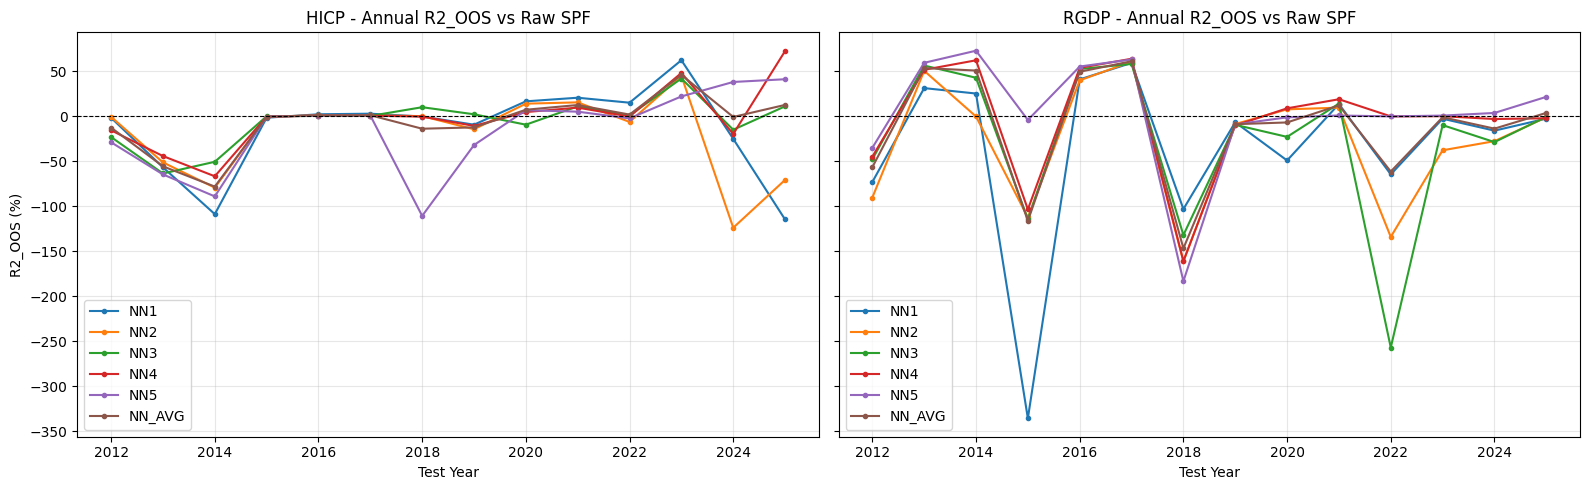

In [13]:
# ====================================================
# Year-by-year R2_OOS plot
# ====================================================

annual_r2 = {}

for target_variable, variable_results in results.items():
    results_to_report = {
        arch_name: variable_results[arch_name]
        for arch_name in archs_to_run
    }
    results_to_report[AVERAGE_ARCH_NAME] = average_architecture_result(
        variable_results,
        archs_to_run,
    )

    for arch_name, res in results_to_report.items():
        years = np.unique(res["test_years"])
        yearly_r2 = []
        for yr in years:
            mask = res["test_years"] == yr
            r2 = r2_oos(res["actuals"][mask], res["preds"][mask])
            yearly_r2.append(r2)

        annual_r2[f"{target_variable}_{arch_name}"] = pd.Series(yearly_r2, index=years)

annual_r2_df = pd.DataFrame(annual_r2) * 100  # in %

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
plot_arches = [*archs_to_run, AVERAGE_ARCH_NAME]

for ax, target_variable in zip(axes, TARGET_VARIABLES):
    for arch_name in plot_arches:
        key = f"{target_variable}_{arch_name}"
        ax.plot(
            annual_r2_df.index,
            annual_r2_df[key],
            marker="o",
            markersize=3,
            label=arch_name,
        )

    # The zero line marks the raw-SPF benchmark: above zero means improvement.
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Test Year")
    ax.set_title(f"{target_variable} - Annual R2_OOS vs Raw SPF")
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel("R2_OOS (%)")
plt.tight_layout()
plt.show()


---
## Step 15: Summary Results Table

In [16]:
# ====================================================
# Summary comparison table
# ====================================================

def rmse(values: np.ndarray) -> float:
    return float(np.sqrt(np.mean(values ** 2)))


summary_rows = []
for target_variable, variable_results in results.items():
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        actual_errors = res["actuals"]
        predicted_errors = res["preds"]
        residual_errors = actual_errors - predicted_errors

        calibration = res.get("calibration", pd.DataFrame())
        mean_alpha = calibration["alpha"].mean() if "alpha" in calibration else np.nan
        mean_clipped_share = (
            calibration["test_prediction_clipped_share"].mean() * 100
            if "test_prediction_clipped_share" in calibration
            else np.nan
        )

        summary_rows.append({
            "Variable": target_variable,
            "Architecture": arch_name,
            "Hidden Layers": str(NN_ARCHITECTURES[arch_name]),
            "R2_zero (%)": f"{r2_oos(actual_errors, predicted_errors) * 100:.4f}",
            "R2_bias (%)": f"{r2_bias(actual_errors, predicted_errors, res['test_years']) * 100:.4f}",
            "Raw SPF RMSE": f"{rmse(actual_errors):.4f}",
            "NN Corrected RMSE": f"{rmse(residual_errors):.4f}",
            "Raw SPF MAE": f"{np.mean(np.abs(actual_errors)):.4f}",
            "NN Corrected MAE": f"{np.mean(np.abs(residual_errors)):.4f}",
            "Mean alpha": f"{mean_alpha:.3f}",
            "Mean clipped (%)": f"{mean_clipped_share:.1f}",
            "N Test Obs": f"{len(actual_errors):,}",
        })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 100)
print("SEPARATE HICP AND RGDP FORECAST-ERROR CORRECTION SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))



SEPARATE HICP AND RGDP FORECAST-ERROR CORRECTION SUMMARY
Variable Architecture     Hidden Layers R2_zero (%) R2_bias (%) Raw SPF RMSE NN Corrected RMSE Raw SPF MAE NN Corrected MAE Mean alpha Mean clipped (%) N Test Obs
    HICP          NN1              [32]     14.7766     19.1669       2.3535            2.1727      1.3651           1.3444      0.626              0.2      2,441
    HICP          NN2          [32, 16]      5.7970     10.6499       2.3535            2.2843      1.3651           1.4240      0.658              0.4      2,441
    HICP          NN3       [32, 16, 8]      5.0645      9.9550       2.3535            2.2932      1.3651           1.3965      0.750              0.0      2,441
    HICP          NN4    [32, 16, 8, 4]      4.2804      9.2113       2.3535            2.3026      1.3651           1.4023      0.710              0.0      2,441
    HICP          NN5 [32, 16, 8, 4, 2]     -0.6834      4.5033       2.3535            2.3616      1.3651           1.4492    

---
## Step 16: Save Predictions to Drive

The saved files include the original SPF forecast, the realized value, the
actual forecast error, the predicted error, and the corrected forecast.

In [17]:
# ====================================================
# Save OOS predictions for each variable and architecture
# ====================================================

output_dir = PROJECT_ROOT / "nn_results"

output_dir.mkdir(parents=True, exist_ok=True)

meta_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "variable",
    "fct_source",
    "rolling_1y_target",
    "rolling_1y_forecast",
    "actual_value",
    "forecast_error",
]

for target_variable, variable_results in results.items():
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        meta = model_data.loc[res["test_indices"], meta_cols].reset_index(drop=True)

        out_df = meta.copy()
        out_df["actual_forecast_error"] = res["actuals"]
        out_df["predicted_error_raw"] = res.get("preds_raw", res["preds"])
        out_df["predicted_error_clipped"] = res.get("preds_clipped", res["preds"])
        out_df["shrinkage_alpha"] = res.get(
            "shrinkage_alpha",
            np.ones(len(out_df), dtype=np.float32),
        )
        out_df["prediction_clip_lower"] = res.get(
            "prediction_clip_lower",
            np.full(len(out_df), np.nan, dtype=np.float32),
        )
        out_df["prediction_clip_upper"] = res.get(
            "prediction_clip_upper",
            np.full(len(out_df), np.nan, dtype=np.float32),
        )
        out_df["predicted_error"] = res["preds"]
        out_df["corrected_forecast"] = (
            out_df["rolling_1y_forecast"] + out_df["predicted_error"]
        )
        out_df["corrected_forecast_error"] = (
            out_df["actual_value"] - out_df["corrected_forecast"]
        )

        out_path = output_dir / f"{target_variable}_{arch_name}_forecast_error_predictions.csv"
        out_df.to_csv(out_path, index=False)
        print(f"Saved {target_variable} {arch_name} predictions to {out_path}")

print("\nDone. All neural network predictions saved.")

Saved HICP NN1 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/HICP_NN1_forecast_error_predictions.csv
Saved HICP NN2 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/HICP_NN2_forecast_error_predictions.csv
Saved HICP NN3 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/HICP_NN3_forecast_error_predictions.csv
Saved HICP NN4 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/HICP_NN4_forecast_error_predictions.csv
Saved HICP NN5 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/HICP_NN5_forecast_error_predictions.csv
Saved RGDP NN1 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/RGDP_NN1_forecast_error_predictions.csv
Saved RGDP NN2 predictions to /content/drive/MyDrive/Final Assignment NN Results2/nn_results/RGDP_NN2_forecast_error_predictions.csv
Saved RGDP NN3 predictions to /content/drive/MyDrive/Final Assignment

---
## Step 17: Plot Actual Values, Average SPF Forecasts, and NN-Corrected Forecasts

This final plot compares the realized macro variable with the average raw SPF
forecast, selected neural-network-corrected forecasts, and an average correction
across all trained NN architectures.

The plot is aggregated by target period and variable, so each point is the
forecaster-average prediction for that target.

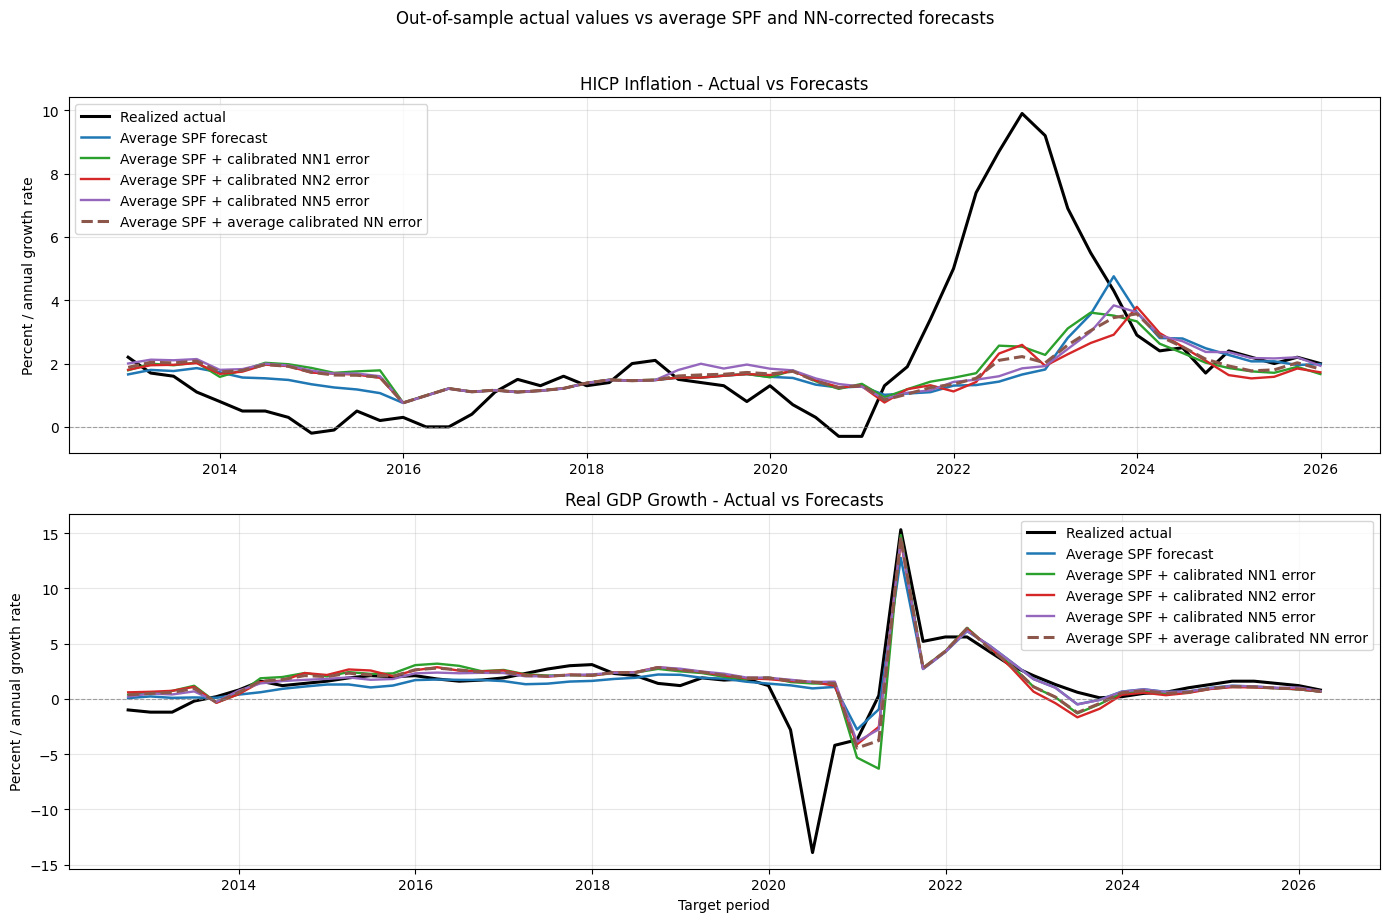

In [18]:
# ====================================================
# Actual vs average SPF vs average NN-corrected forecasts
# ====================================================

PLOT_ARCHES = ["NN1", "NN2", "NN5"]
AVERAGE_ARCH_NAME = "NN_AVG"

plot_frames = []
plot_meta_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "variable",
    "fct_source",
    "rolling_1y_target",
    "target_date",
    "rolling_1y_forecast",
    "actual_value",
]


# Build one plotting frame from indexed predicted forecast errors.
def build_prediction_frame_from_series(
    target_variable: str,
    architecture: str,
    prediction_series: pd.Series,
) -> pd.DataFrame:
    # the series index = original model_data row numbers, so .loc recovers metadata
    meta = model_data.loc[prediction_series.index, plot_meta_cols].reset_index(drop=True)
    meta["architecture"] = architecture
    meta["predicted_error"] = prediction_series.to_numpy(dtype=float)
    meta["nn_corrected_forecast"] = (
        meta["rolling_1y_forecast"] + meta["predicted_error"]
    )
    return meta


for target_variable in TARGET_VARIABLES:
    for arch_name in PLOT_ARCHES:
        res = results[target_variable][arch_name]
        pred_series = pd.Series(res["preds"], index=res["test_indices"], name=arch_name)
        plot_frames.append(
            build_prediction_frame_from_series(target_variable, arch_name, pred_series)
        )

    # NN_AVG: align predictions by test row, then take the row-wise mean
    aligned_predictions = pd.concat(
        [
            pd.Series(
                results[target_variable][arch]["preds"],
                index=results[target_variable][arch]["test_indices"],
                name=arch,
            )
            for arch in archs_to_run
        ],
        axis=1,
        join="inner",
    ).sort_index()

    avg_prediction_series = aligned_predictions.mean(axis=1).rename(AVERAGE_ARCH_NAME)
    plot_frames.append(
        build_prediction_frame_from_series(
            target_variable,
            AVERAGE_ARCH_NAME,
            avg_prediction_series,
        )
    )

prediction_plot_data = pd.concat(plot_frames, ignore_index=True)

prediction_plot_data["plot_date"] = pd.to_datetime(prediction_plot_data["target_date"])

# Forecaster-level rows -> one point per target period, the level the plot needs.
average_forecasts = (
    prediction_plot_data
    .groupby(["variable", "architecture", "rolling_1y_target", "plot_date"], as_index=False)
    .agg(
        actual_value=("actual_value", "mean"),
        average_spf_forecast=("rolling_1y_forecast", "mean"),
        average_nn_corrected_forecast=("nn_corrected_forecast", "mean"),
        n_forecasters=("fct_source", "nunique"),
    )
    .sort_values(["variable", "architecture", "plot_date"])
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
variable_titles = {
    "HICP": "HICP Inflation",
    "RGDP": "Real GDP Growth",
}
arch_colors = {
    "NN1": "tab:green",
    "NN2": "tab:red",
    "NN3": "tab:orange",
    "NN5": "tab:purple",
    AVERAGE_ARCH_NAME: "tab:brown",
}
arch_linestyles = {
    "NN1": "-",
    "NN2": "-",
    "NN3": "-",
    "NN5": "-",
    AVERAGE_ARCH_NAME: "--",
}

line_arches = [*PLOT_ARCHES, AVERAGE_ARCH_NAME]

for ax, target_variable in zip(axes, TARGET_VARIABLES):
    variable_df = average_forecasts.loc[
        average_forecasts["variable"] == target_variable
    ].copy()
    base_df = variable_df.loc[variable_df["architecture"] == PLOT_ARCHES[0]].copy()

    ax.plot(
        base_df["plot_date"],
        base_df["actual_value"],
        color="black",
        linewidth=2.2,
        label="Realized actual",
    )
    ax.plot(
        base_df["plot_date"],
        base_df["average_spf_forecast"],
        color="tab:blue",
        linewidth=1.8,
        label="Average SPF forecast",
    )

    for arch_name in line_arches:
        series_df = variable_df.loc[variable_df["architecture"] == arch_name].copy()
        label = (
            "Average SPF + average calibrated NN error"
            if arch_name == AVERAGE_ARCH_NAME
            else f"Average SPF + calibrated {arch_name} error"
        )
        linewidth = 2.2 if arch_name == AVERAGE_ARCH_NAME else 1.7

        ax.plot(
            series_df["plot_date"],
            series_df["average_nn_corrected_forecast"],
            linewidth=linewidth,
            linestyle=arch_linestyles[arch_name],
            color=arch_colors[arch_name],
            label=label,
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_title(f"{variable_titles[target_variable]} - Actual vs Forecasts")
    ax.set_ylabel("Percent / annual growth rate")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Target period")
fig.suptitle(
    "Out-of-sample actual values vs average SPF and NN-corrected forecasts",
    y=1.02,
)
plt.tight_layout()
plt.show()


---
## Step 18: Forecast Comparison Table and Statistical Test

This table directly asks whether adding the neural network's predicted error
improves the SPF forecast. It includes each trained architecture and an
`NN_AVG` row that averages the calibrated predictions across all trained NN
architectures.

The comparison is done at the target-period average level, not at the
individual-forecaster row level. This matters because many forecasters predict
the same target period, so those rows are not independent observations for a
statistical test.

The test is a Diebold-Mariano-style loss-difference test with Newey-West
standard errors:

```text
loss_difference_t = raw_SPF_loss_t - NN_corrected_loss_t
```

A positive mean loss difference means the NN-corrected forecast has lower loss.
The reported p-values are two-sided tests of equal predictive accuracy.

In [19]:
# ====================================================
# Forecast comparison table with DM-style HAC tests
# ====================================================

DM_MAX_LAG = 4
AVERAGE_ARCH_NAME = "NN_AVG"
COMPARISON_ARCHES = ["NN1", "NN2", "NN3", "NN4", "NN5"]
COMPARISON_ARCHES_WITH_AVG = [*COMPARISON_ARCHES, AVERAGE_ARCH_NAME]


# RMSE helper local to the final comparison table.
def metric_rmse(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2)))


# Test whether the mean loss difference differs from zero.
# Positive loss_diff means the NN-corrected forecast has smaller loss than
# the raw SPF forecast. The Newey-West variance accounts for serial correlation.
def newey_west_mean_test(loss_diff: np.ndarray, max_lag: int = DM_MAX_LAG) -> dict:
    d = np.asarray(loss_diff, dtype=float)
    n = len(d)

    mean_diff = float(np.mean(d))
    demeaned = d - mean_diff
    lag = min(max_lag, n - 1)

    long_run_var = float(np.dot(demeaned, demeaned) / n)
    for k in range(1, lag + 1):
        gamma_k = float(np.dot(demeaned[k:], demeaned[:-k]) / n)
        weight = 1.0 - k / (lag + 1)
        long_run_var += 2.0 * weight * gamma_k

    se_mean = float(np.sqrt(long_run_var / n))
    stat = mean_diff / se_mean
    p_two_sided = 2.0 * stats.norm.sf(abs(stat))

    return {
        "n": n,
        "mean_diff": mean_diff,
        "stat": float(stat),
        "p_two_sided": float(p_two_sided),
    }


# Human-readable verdict based on RMSE improvement and squared-loss test.
def comparison_verdict(improvement_pct: float, p_value: float) -> str:
    direction = "better" if improvement_pct > 0 else "worse" if improvement_pct < 0 else "same"
    if direction == "same":
        return "Same RMSE"

    suffix = "statistically significant" if p_value < 0.05 else "not statistically significant"
    return f"NN {direction} ({suffix})"


# Return indexed calibrated predictions for one architecture or NN_AVG.
def get_prediction_series(target_variable: str, arch_name: str) -> pd.Series:
    if arch_name == AVERAGE_ARCH_NAME:
        aligned_predictions = pd.concat(
            [
                pd.Series(
                    results[target_variable][arch]["preds"],
                    index=results[target_variable][arch]["test_indices"],
                    name=arch,
                )
                for arch in COMPARISON_ARCHES
            ],
            axis=1,
            join="inner",
        ).sort_index()
        return aligned_predictions.mean(axis=1).rename(AVERAGE_ARCH_NAME)

    res = results[target_variable][arch_name]
    return pd.Series(res["preds"], index=res["test_indices"], name=arch_name)


# Build target-period average raw and NN-corrected forecasts.
def build_architecture_forecast_frame(target_variable: str, arch_name: str) -> pd.DataFrame:
    prediction_series = get_prediction_series(target_variable, arch_name)

    needed_cols = [
        "survey_round",
        "survey_year",
        "survey_quarter",
        "variable",
        "fct_source",
        "rolling_1y_target",
        "target_date",
        "rolling_1y_forecast",
        "actual_value",
    ]

    meta = model_data.loc[prediction_series.index, needed_cols].reset_index(drop=True)
    meta["predicted_error"] = prediction_series.to_numpy(dtype=float)
    meta["nn_corrected_forecast"] = meta["rolling_1y_forecast"] + meta["predicted_error"]
    meta["plot_date"] = pd.to_datetime(meta["target_date"])

    grouped = (
        meta
        .groupby(["variable", "rolling_1y_target", "plot_date"], as_index=False)
        .agg(
            actual_value=("actual_value", "mean"),
            average_spf_forecast=("rolling_1y_forecast", "mean"),
            average_nn_corrected_forecast=("nn_corrected_forecast", "mean"),
            n_forecasters=("fct_source", "nunique"),
        )
        .sort_values("plot_date")
    )

    grouped["raw_error"] = grouped["actual_value"] - grouped["average_spf_forecast"]
    grouped["nn_corrected_error"] = (
        grouped["actual_value"] - grouped["average_nn_corrected_forecast"]
    )
    return grouped


comparison_rows = []
comparison_frames = {}

for target_variable in TARGET_VARIABLES:
    comparison_frames[target_variable] = {}

    for arch_name in COMPARISON_ARCHES_WITH_AVG:
        forecast_frame = build_architecture_forecast_frame(target_variable, arch_name)
        comparison_frames[target_variable][arch_name] = forecast_frame

        raw_error = forecast_frame["raw_error"].to_numpy()
        corrected_error = forecast_frame["nn_corrected_error"].to_numpy()

        raw_rmse = metric_rmse(raw_error)
        corrected_rmse = metric_rmse(corrected_error)
        raw_mae = float(np.mean(np.abs(raw_error)))
        corrected_mae = float(np.mean(np.abs(corrected_error)))

        rmse_improvement_pct = 100.0 * (raw_rmse - corrected_rmse) / raw_rmse
        mae_improvement_pct = 100.0 * (raw_mae - corrected_mae) / raw_mae

        squared_loss_diff = raw_error ** 2 - corrected_error ** 2
        absolute_loss_diff = np.abs(raw_error) - np.abs(corrected_error)

        squared_test = newey_west_mean_test(squared_loss_diff)
        absolute_test = newey_west_mean_test(absolute_loss_diff)

        comparison_rows.append({
            "Variable": target_variable,
            "Architecture": arch_name,
            "N target periods": int(len(forecast_frame)),
            "Raw SPF RMSE": raw_rmse,
            "NN Corrected RMSE": corrected_rmse,
            "RMSE improvement (%)": rmse_improvement_pct,
            "Raw SPF MAE": raw_mae,
            "NN Corrected MAE": corrected_mae,
            "MAE improvement (%)": mae_improvement_pct,
            "Mean squared-loss diff": squared_test["mean_diff"],
            "DM stat squared loss": squared_test["stat"],
            "DM p squared loss": squared_test["p_two_sided"],
            "Mean absolute-loss diff": absolute_test["mean_diff"],
            "DM stat absolute loss": absolute_test["stat"],
            "DM p absolute loss": absolute_test["p_two_sided"],
            "RMSE verdict": comparison_verdict(
                rmse_improvement_pct,
                squared_test["p_two_sided"],
            ),
        })

forecast_comparison_df = pd.DataFrame(comparison_rows)

display_cols = [
    "Variable",
    "Architecture",
    "N target periods",
    "Raw SPF RMSE",
    "NN Corrected RMSE",
    "RMSE improvement (%)",
    "Raw SPF MAE",
    "NN Corrected MAE",
    "MAE improvement (%)",
    "DM stat squared loss",
    "DM p squared loss",
    "DM p absolute loss",
    "RMSE verdict",
]

formatted_comparison = forecast_comparison_df[display_cols].copy()
numeric_format_cols = [
    "Raw SPF RMSE",
    "NN Corrected RMSE",
    "RMSE improvement (%)",
    "Raw SPF MAE",
    "NN Corrected MAE",
    "MAE improvement (%)",
    "DM stat squared loss",
    "DM p squared loss",
    "DM p absolute loss",
]
for col in numeric_format_cols:
    formatted_comparison[col] = formatted_comparison[col].map(lambda x: f"{x:.4f}")

print("Forecast comparison using target-period average forecasts")
print("Positive improvement means the NN-corrected forecast has lower error.")
print("DM p-values are two-sided; p < 0.05 is treated as statistically significant.")
display(formatted_comparison)


Forecast comparison using target-period average forecasts
Positive improvement means the NN-corrected forecast has lower error.
DM p-values are two-sided; p < 0.05 is treated as statistically significant.


,Variable,Architecture,N target periods,Raw SPF RMSE,NN Corrected RMSE,RMSE improvement (%),Raw SPF MAE,NN Corrected MAE,MAE improvement (%),DM stat squared loss,DM p squared loss,DM p absolute loss,RMSE verdict
0,HICP,NN1,53,2.2856,2.1344,6.6151,1.2821,1.2999,-1.3879,0.9355,0.3495,0.8197,NN better (not statistically significant)
1,HICP,NN2,53,2.2856,2.2481,1.6432,1.2821,1.3864,-8.1283,0.3607,0.7183,0.0800,NN better (not statistically significant)
2,HICP,NN3,53,2.2856,2.2494,1.5866,1.2821,1.3477,-5.1103,0.4904,0.6239,0.1151,NN better (not statistically significant)
3,HICP,NN4,53,2.2856,2.2614,1.0624,1.2821,1.3547,-5.6580,0.3540,0.7234,0.0907,NN better (not statistically significant)
4,HICP,NN5,53,2.2856,2.3127,-1.1850,1.2821,1.3874,-8.2056,-0.6474,0.5174,0.0291,NN worse (not statistically significant)
5,HICP,NN_AVG,53,2.2856,2.2377,2.0956,1.2821,1.3527,-5.5046,0.5451,0.5857,0.1491,NN better (not statistically significant)
6,RGDP,NN1,55,2.3456,2.5971,-10.7192,1.0429,1.2661,-21.4033,-1.4921,0.1357,0.0421,NN worse (not statistically significant)
7,RGDP,NN2,55,2.3456,2.4912,-6.2048,1.0429,1.2133,-16.3383,-1.7039,0.0884,0.0592,NN worse (not statistically significant)
8,RGDP,NN3,55,2.3456,2.5843,-10.1754,1.0429,1.2537,-20.2155,-1.7021,0.0887,0.0661,NN worse (not statistically significant)
9,RGDP,NN4,55,2.3456,2.4492,-4.4158,1.0429,1.0786,-3.4242,-1.0482,0.2945,0.6471,NN worse (not statistically significant)


---
## Summary

This notebook trains feed-forward neural networks to predict SPF rolling
one-year-ahead forecast errors.

| Step | Description |
|---|---|
| 1 | Load `final_model_dataset.csv` from Google Drive |
| 2 | Select the forecast-error target and numeric features |
| 3 | Build chronological expanding-window splits |
| 4 | Define MLP architectures with dropout |
| 5 | Train separate HICP and RGDP models |
| 6 | Evaluate corrections against both the raw SPF forecast and a rolling historical bias correction |
| 7 | Save out-of-sample corrected forecasts |
| 8 | Calibrate NN corrections with train-window clipping and validation OLS shrinkage |
| 9 | Plot actual values against average SPF and NN-corrected forecasts |
| 10 | Compare raw SPF vs NN-corrected forecasts, including the all-NN average, with statistical tests |

The first clean run drops the other SPF horizon forecasts and keeps only
`rolling_1y_forecast` as the forecast being corrected. The two reported
R2 metrics answer different questions: `R2_zero` tests whether the network
improves on doing no correction, while `R2_bias` tests whether it improves
on the simple rule of correcting by the historical mean forecast error.
